# 06 Channels and Inflation Target

Replicate Figures 6-9. This version uses the exact stacked Figure 6 percentile system and expands Figure 9 to include IRFs, variance decomposition, and historical contribution panels.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import get_paths, ensure_output_dirs
paths = get_paths()
ensure_output_dirs(paths)
print('Project root:', PROJECT_ROOT)
print('Original root:', paths.original_root)

Project root: C:\Users\asus\Desktop\Inequality_CGKS_replication_folder\python_replication
Original root: C:\Users\asus\Desktop\Inequality_CGKS_replication_folder\replication_folder


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from src.data import load_cex_short
from src.local_projection import (
    run_stacked_lp, lp_summary, run_percentile_spread_system,
    percentile_system_summary, variance_decomposition, historical_contribution,
)
from src.plots import savefig, paper_style, shade_recessions
from src.metrics import write_table

df = load_cex_short(paths)
paper_style()

## Figure 6: exact stacked percentile-spread system

In [3]:
percentile_specs = [
    ('LNYBTIMP_SA', 'Income'), ('LNSALARYIMP_SA', 'Earnings'),
    ('LNTOTALEXP3_SA', 'Expenditure'), ('LNCONS_SA', 'Consumption')
]
fig6_results = {base: run_percentile_spread_system(df, base) for base, _ in percentile_specs}
fig6_summary = percentile_system_summary(fig6_results)
fig6_summary['paper_p_value'] = fig6_summary['variable'].map({
    'LNYBTIMP_SA': 0.000,
    'LNSALARYIMP_SA': 0.209,
    'LNTOTALEXP3_SA': 0.000,
    'LNCONS_SA': 0.000,
})
fig6_summary['same_5pct_equality_conclusion'] = (fig6_summary['equality_p_value'] < 0.05) == (fig6_summary['paper_p_value'] < 0.05)
write_table(fig6_summary, paths.tables / '06_figure6_percentile_system.csv')
fig6_summary

,variable,equality_p_value,equality_f_stat,nobs,p90_peak_irf,p10_trough_irf,covariance,paper_p_value,same_5pct_equality_conclusion
0,LNYBTIMP_SA,4.704785e-09,3.912822,4326,0.029041,-0.061194,driscoll-kraay,0.000,True
1,LNSALARYIMP_SA,4.277925e-01,1.025001,4326,0.023571,-0.045769,driscoll-kraay,0.209,True
2,LNTOTALEXP3_SA,2.008019e-05,2.811585,4368,0.172556,-0.063433,driscoll-kraay,0.000,True
3,LNCONS_SA,1.110223e-16,13.528495,4368,0.111627,-0.031136,driscoll-kraay,0.000,True


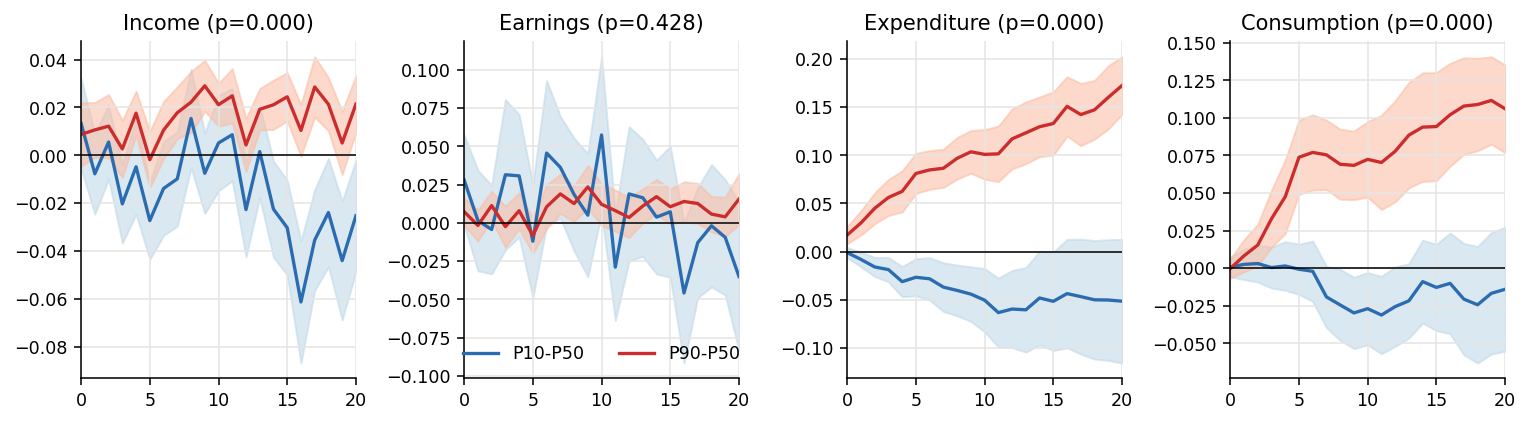

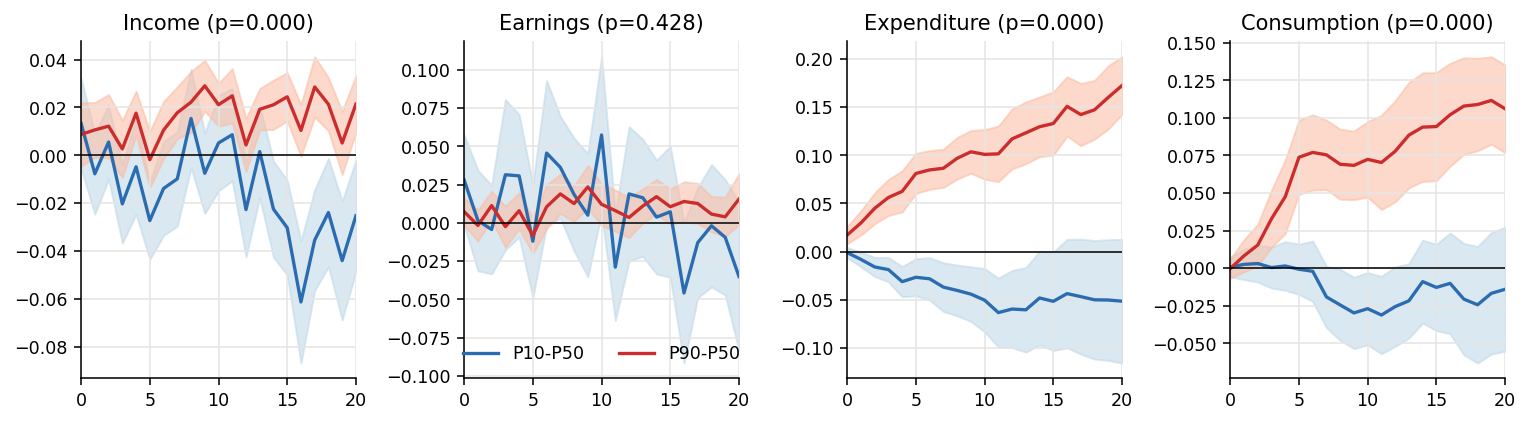

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(11, 3.1), sharex=True)
for ax, (base, label) in zip(axes, percentile_specs):
    res = fig6_results[base]
    h = res.horizons
    ax.fill_between(h, res.p10_irf - res.p10_se, res.p10_irf + res.p10_se, color='#bdd7e7', alpha=0.55)
    ax.fill_between(h, res.p90_irf - res.p90_se, res.p90_irf + res.p90_se, color='#fcbba1', alpha=0.55)
    ax.plot(h, res.p10_irf, color='#2b6cb0', lw=1.7, label='P10-P50')
    ax.plot(h, res.p90_irf, color='#cc2c2c', lw=1.7, label='P90-P50')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{label} (p={res.equality_pvalue:.3f})')
    ax.set_xlim(0, 20)
axes[1].legend(frameon=False, ncol=2, loc='lower center')
savefig(fig, paths.figures / 'figure6_percentile_channels.png')
fig

## Figure 7: consumption-quintile persistence

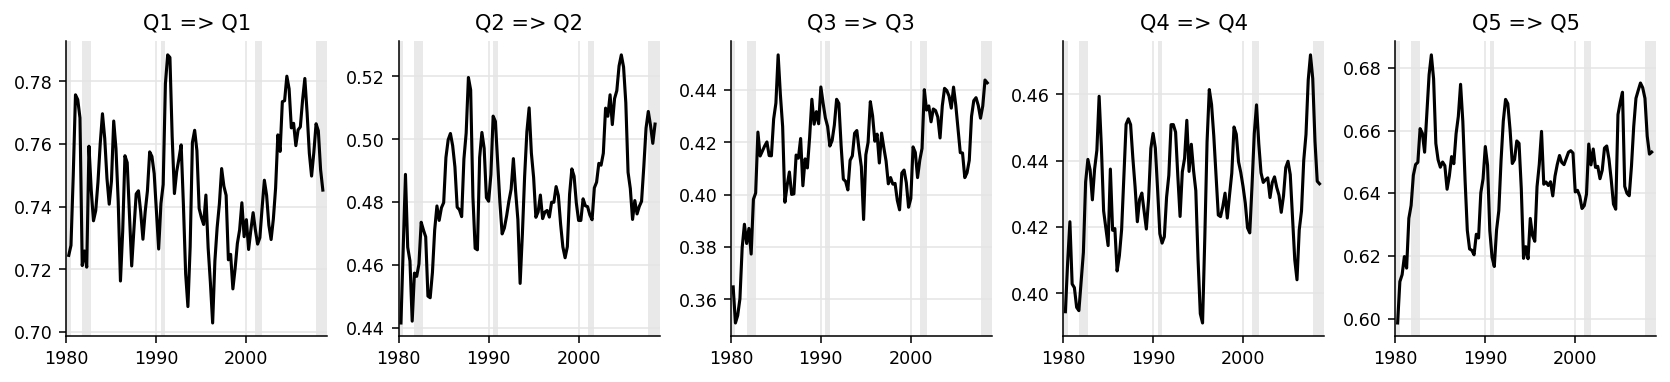

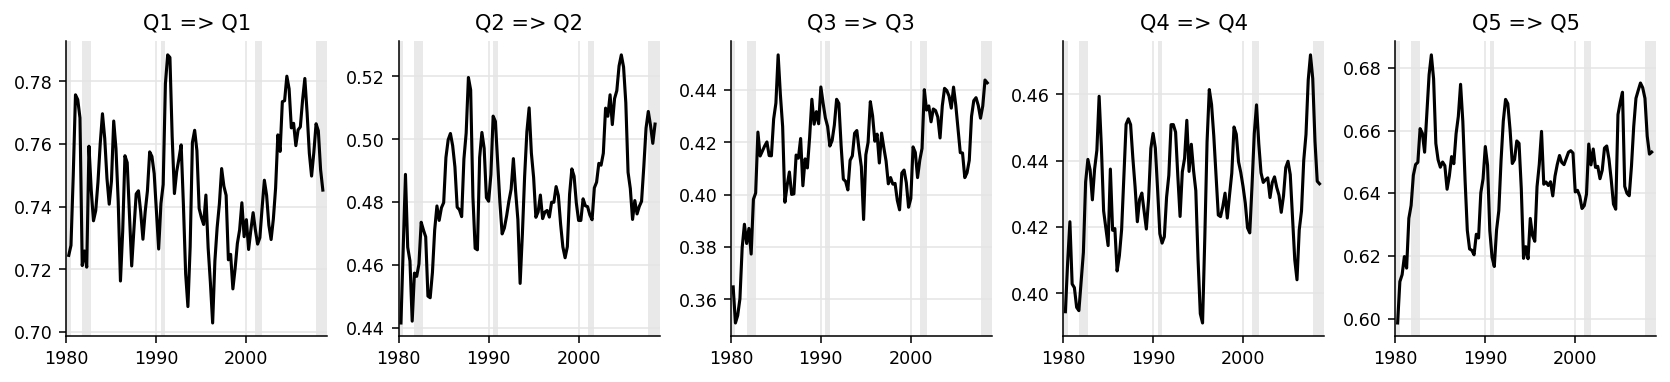

In [5]:
transition_vars = ['P1_11_CONS_SA','P1_22_CONS_SA','P1_33_CONS_SA','P1_44_CONS_SA','P1_55_CONS_SA']
labels = ['Q1 => Q1','Q2 => Q2','Q3 => Q3','Q4 => Q4','Q5 => Q5']
fig, axes = plt.subplots(1, 5, figsize=(12, 2.8), sharex=True)
for ax, var, label in zip(axes, transition_vars, labels):
    shade_recessions(ax)
    ax.plot(df['time'], df[var].rolling(3, center=True).mean(), color='black', lw=1.6)
    ax.set_title(label)
    ax.set_xlim(1980, 2009)
savefig(fig, paths.figures / 'figure7_transition_probabilities_ts.png')

shock_sq = df.copy()
shock_sq['sh_rr_sq'] = shock_sq['sh_rr'] ** 2
transition_results = {}
for var in transition_vars:
    shock_sq['D_' + var] = shock_sq[var].diff()
    transition_results[var] = run_stacked_lp(shock_sq, 'D_' + var, shock_var='sh_rr_sq')
write_table(lp_summary(transition_results), paths.tables / '06_figure7_transition_irfs.csv')
fig

## Figure 8: high-minus-low net-worth group gaps

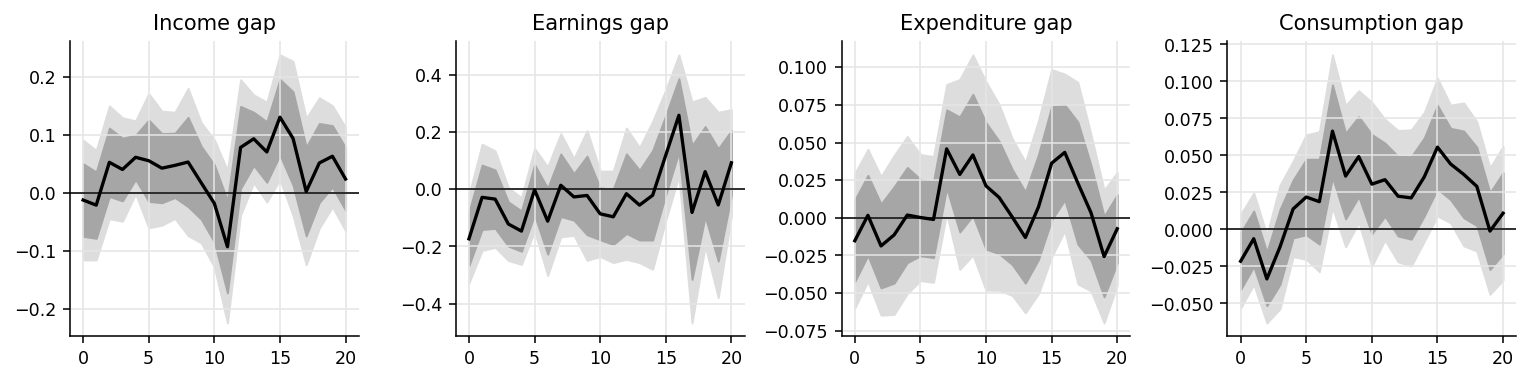

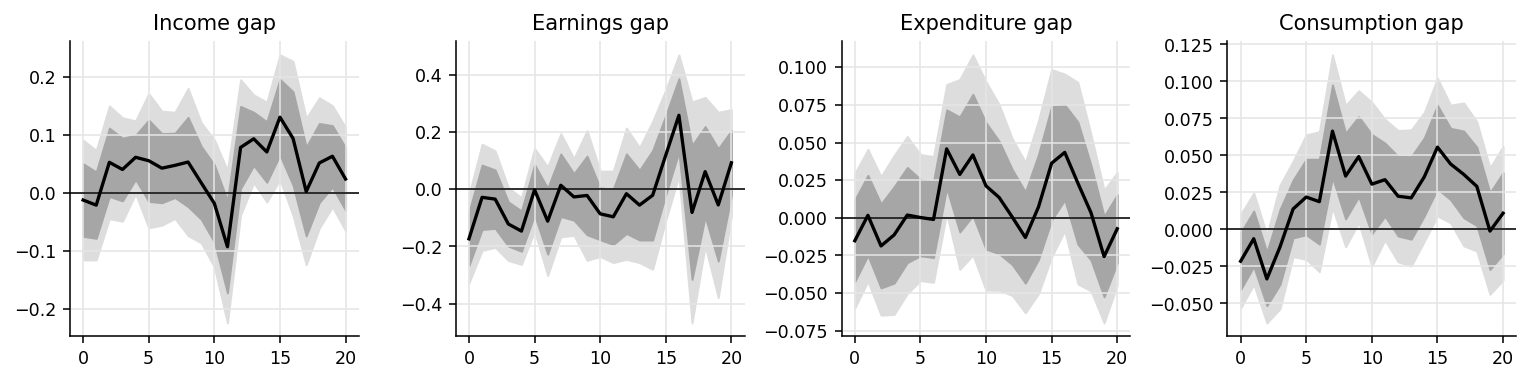

In [6]:
gap_df = df.copy()
gap_specs = [
    ('D_LNYBTIMP2_SA', 'Income', 'LNYBTIMP2_SA', 'LNYBTIMP1_SA'),
    ('D_LNSALARYIMP2_SA', 'Earnings', 'LNSALARYIMP2_SA', 'LNSALARYIMP1_SA'),
    ('D_LNTOTALEXP2_SA', 'Expenditure', 'LNTOTALEXP2_SA', 'LNTOTALEXP1_SA'),
    ('D_LNCONS2_SA', 'Consumption', 'LNCONS2_SA', 'LNCONS1_SA'),
]
for new, _, hi, lo in gap_specs:
    gap_df[new] = gap_df[hi] - gap_df[lo]
gap_results = {new: run_stacked_lp(gap_df, new, cumulative=False) for new, _, _, _ in gap_specs}
gap_summary = lp_summary(gap_results)
gap_summary['paper_p_value'] = gap_summary['variable'].map({
    'D_LNYBTIMP2_SA': 0.078,
    'D_LNSALARYIMP2_SA': 0.024,
    'D_LNTOTALEXP2_SA': 0.021,
    'D_LNCONS2_SA': 0.000,
})
gap_summary['same_5pct_conclusion'] = (gap_summary['p_value'] < 0.05) == (gap_summary['paper_p_value'] < 0.05)
write_table(gap_summary, paths.tables / '06_figure8_networth_gap_irfs.csv')
fig, axes = plt.subplots(1, 4, figsize=(11, 2.8), sharex=True)
for ax, (var, label, _, _) in zip(axes, gap_specs):
    res = gap_results[var]
    ax.fill_between(res.horizons, res.lower_165se, res.upper_165se, color='#dddddd')
    ax.fill_between(res.horizons, res.lower_1se, res.upper_1se, color='#a6a6a6')
    ax.plot(res.horizons, res.irf, color='black', lw=1.7)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{label} gap')
savefig(fig, paths.figures / 'figure8_networth_gap_irfs.png')
fig

## Figure 9: inflation-target shocks

In [7]:
pi_df = df.copy()
pi_df['neg_sh_pi'] = -pi_df['sh_pi']
pi_vars = [('D_SD_LNYBTIMP2_SA','Income'), ('D_SD_LNSALARYIMP_SA','Earnings'), ('D_SD_LNTOTALEXP3_SA','Expenditure'), ('D_SD_LNCONS_SA','Consumption')]
pi_results = {var: run_stacked_lp(pi_df, var, shock_var='neg_sh_pi') for var, _ in pi_vars}
pi_summary = lp_summary(pi_results)
write_table(pi_summary, paths.tables / '06_figure9_inflation_target_irfs.csv')

pi_vd = []
for var, label in pi_vars:
    frame = variance_decomposition(pi_df, var, shock_var='neg_sh_pi')
    frame['variable'] = var
    frame['title'] = label
    pi_vd.append(frame)
pi_vd = pd.concat(pi_vd, ignore_index=True)
write_table(pi_vd, paths.tables / '06_figure9_inflation_target_variance.csv')

pi_hist = {var: historical_contribution(pi_df, var, shock_var='neg_sh_pi') for var, _ in pi_vars}
write_table(pd.concat([v.assign(variable=k) for k, v in pi_hist.items()]), paths.tables / '06_figure9_inflation_target_history.csv')
pi_summary

C:\Users\asus\Desktop\Inequality_CGKS_replication_folder\python_replication\src\local_projection.py:472: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.06434358656406414' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  sim_all.loc[t] = sum(fit.params[k] * row[k] for k in fit.params.index)
C:\Users\asus\Desktop\Inequality_CGKS_replication_folder\python_replication\src\local_projection.py:473: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.05826331556706424' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  sim_no_shock.loc[t] = sum(fit.params[k] * row0[k] for k in fit.params.index)


C:\Users\asus\Desktop\Inequality_CGKS_replication_folder\python_replication\src\local_projection.py:472: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.0031859700102360652' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  sim_all.loc[t] = sum(fit.params[k] * row[k] for k in fit.params.index)
C:\Users\asus\Desktop\Inequality_CGKS_replication_folder\python_replication\src\local_projection.py:473: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.021385971786849457' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  sim_no_shock.loc[t] = sum(fit.params[k] * row0[k] for k in fit.params.index)


,variable,p_value,f_stat,nobs,peak_irf,trough_irf,h_peak,covariance
0,D_SD_LNYBTIMP2_SA,1.110223e-16,85.098869,2163,0.018081,-0.007916,11,driscoll-kraay
1,D_SD_LNSALARYIMP_SA,1.110223e-16,51.115805,2163,0.036252,-0.003299,18,driscoll-kraay
2,D_SD_LNTOTALEXP3_SA,1.110223e-16,34.341598,2184,0.071776,0.000519,20,driscoll-kraay
3,D_SD_LNCONS_SA,1.110223e-16,62.497412,2184,0.068649,0.006158,17,driscoll-kraay


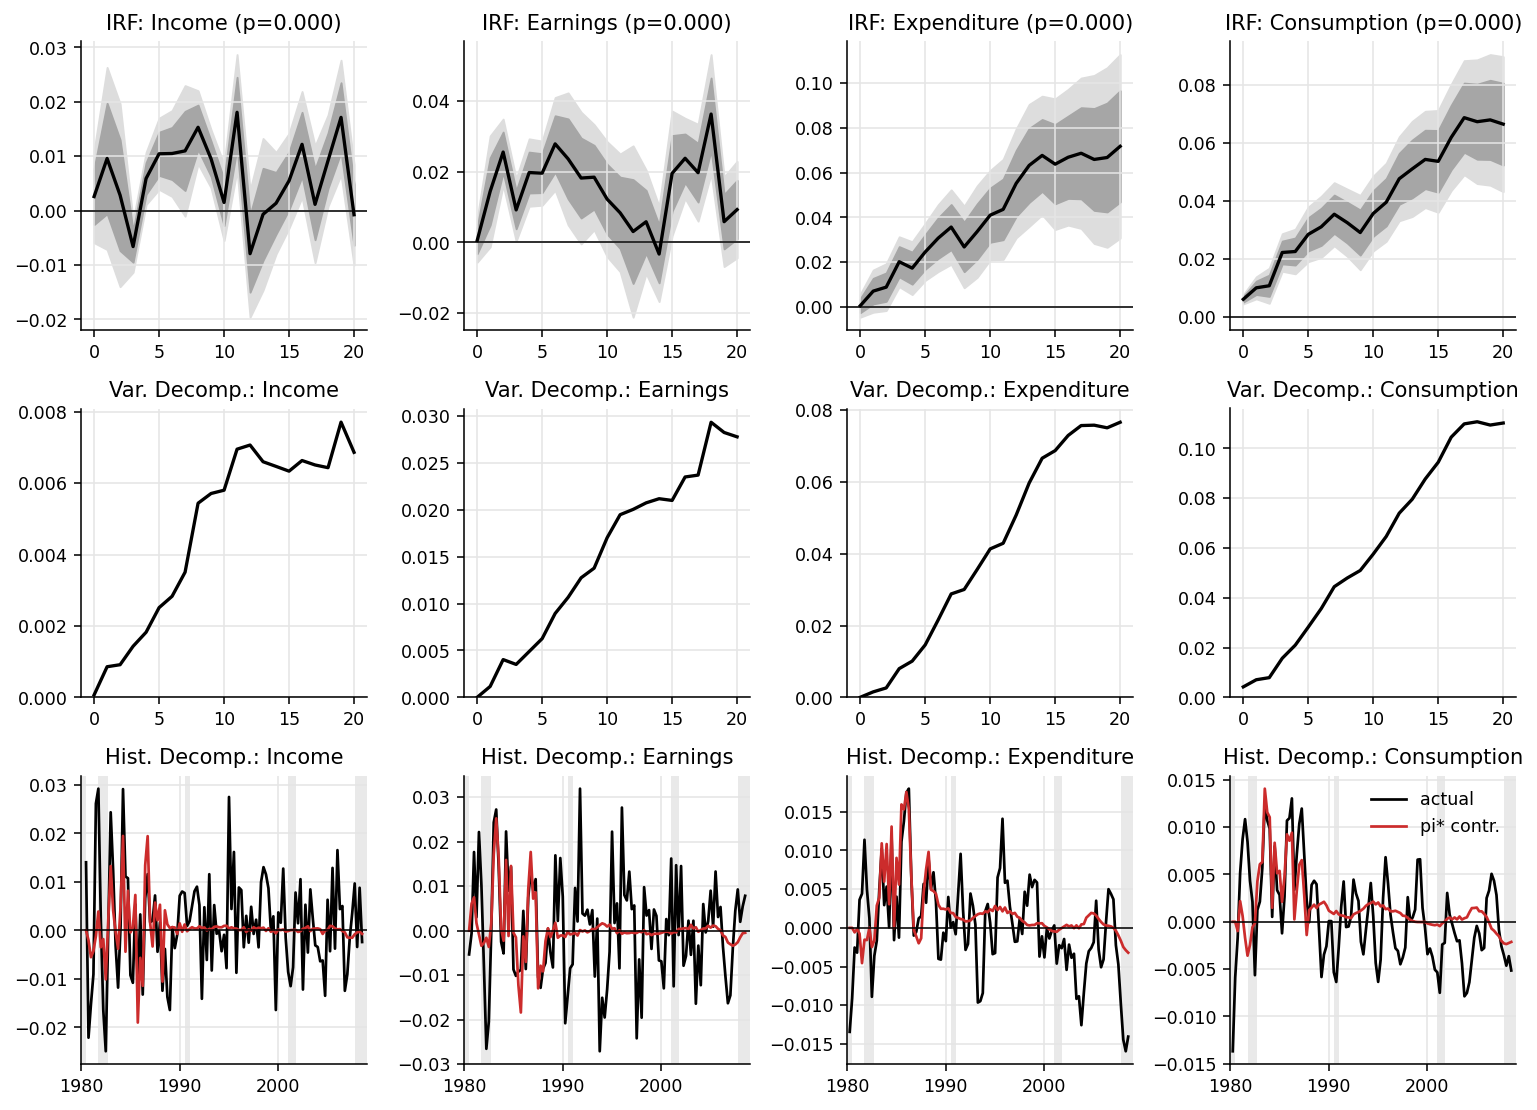

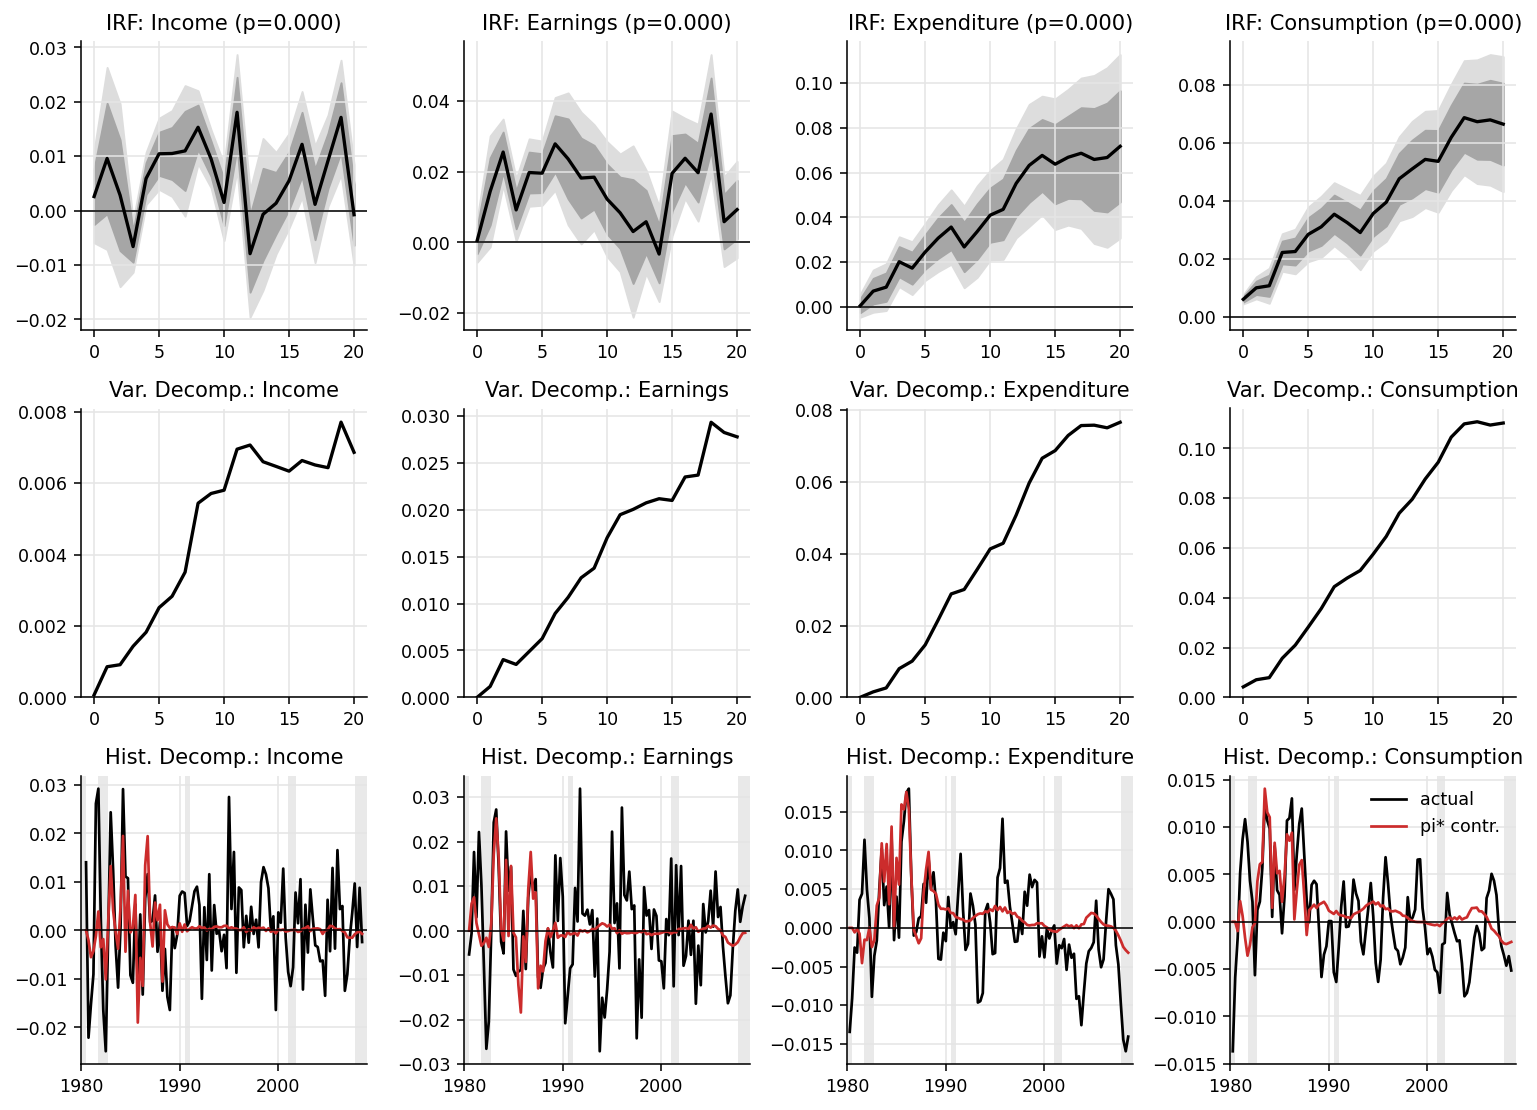

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(11, 8), sharex='row')
for col, (var, label) in enumerate(pi_vars):
    res = pi_results[var]
    ax = axes[0, col]
    ax.fill_between(res.horizons, res.lower_165se, res.upper_165se, color='#dddddd')
    ax.fill_between(res.horizons, res.lower_1se, res.upper_1se, color='#a6a6a6')
    ax.plot(res.horizons, res.irf, color='black', lw=1.7)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'IRF: {label} (p={res.pvalue:.3f})')

    ax = axes[1, col]
    frame = pi_vd[pi_vd['variable'] == var]
    ax.plot(frame['horizon'], frame['contribution'], color='black', lw=1.7)
    ax.set_title(f'Var. Decomp.: {label}')
    ax.set_ylim(bottom=0)

    ax = axes[2, col]
    hist_frame = pi_hist[var]
    shade_recessions(ax)
    ax.plot(hist_frame['time'], hist_frame['actual_ma3'], color='black', lw=1.4, label='actual')
    ax.plot(hist_frame['time'], hist_frame['contribution_ma3'], color='#cc2c2c', lw=1.4, label='pi* contr.')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'Hist. Decomp.: {label}')
    ax.set_xlim(1980, 2009)
axes[2, -1].legend(frameon=False)
savefig(fig, paths.figures / 'figure9_inflation_target_full.png')
fig

## Deviation Note

Figure 6 now matches the original joint-test structure. Figure 9 now includes IRF, variance-decomposition, and historical-contribution panels. Remaining numerical differences primarily reflect Python versus Stata covariance implementation and the fact that the time-varying inflation-target model itself is not re-estimated from raw macro data.